Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB
None

Missing Values:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca

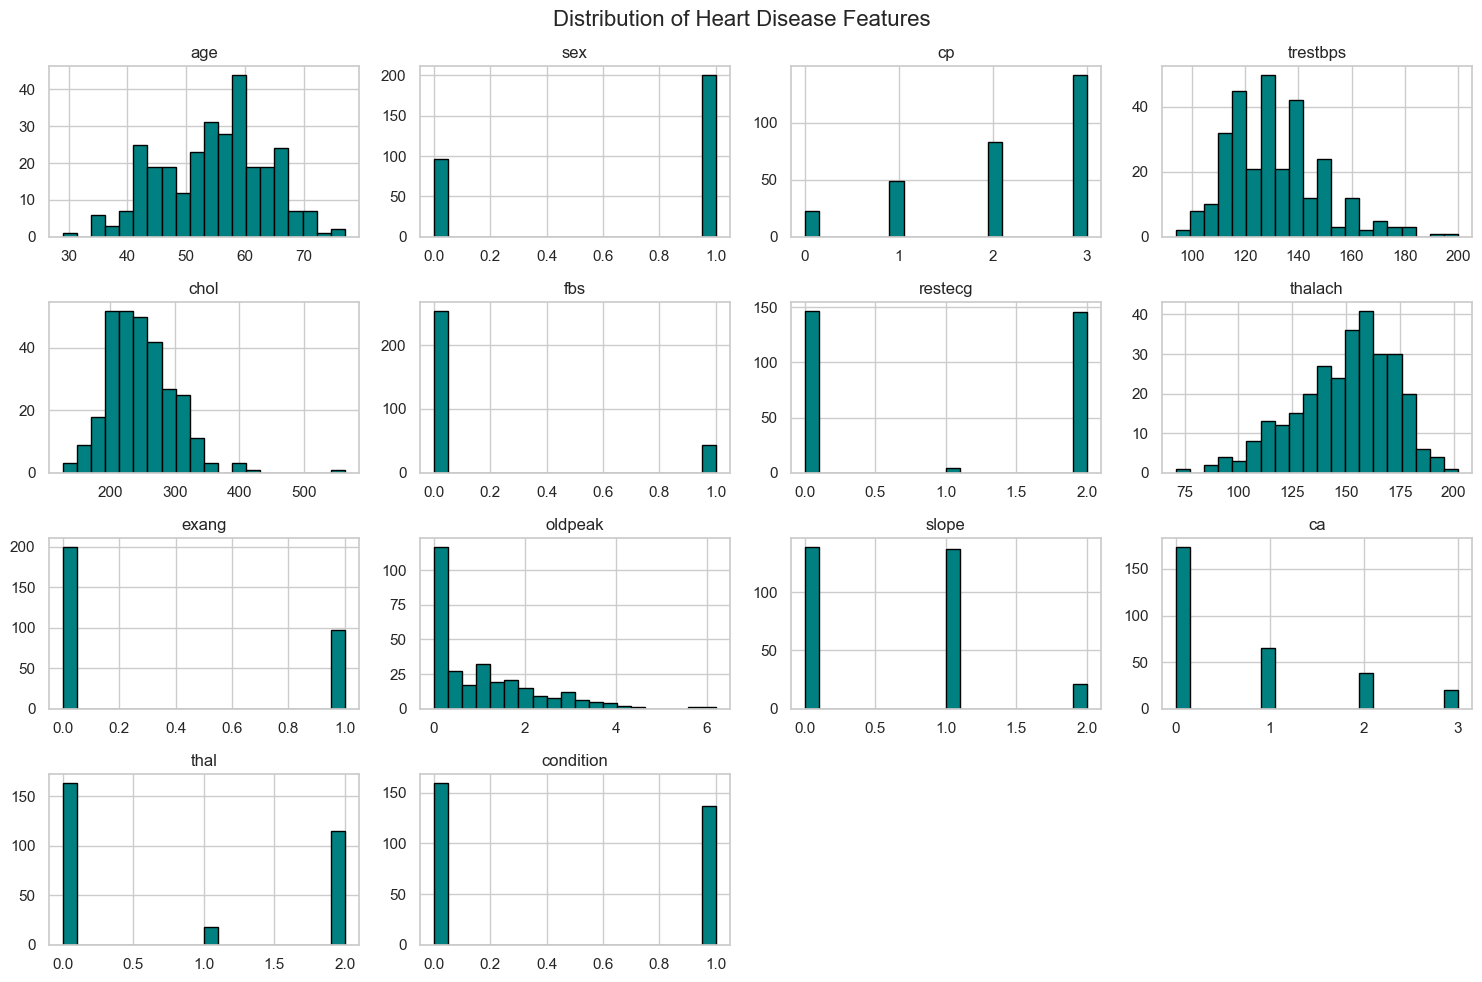

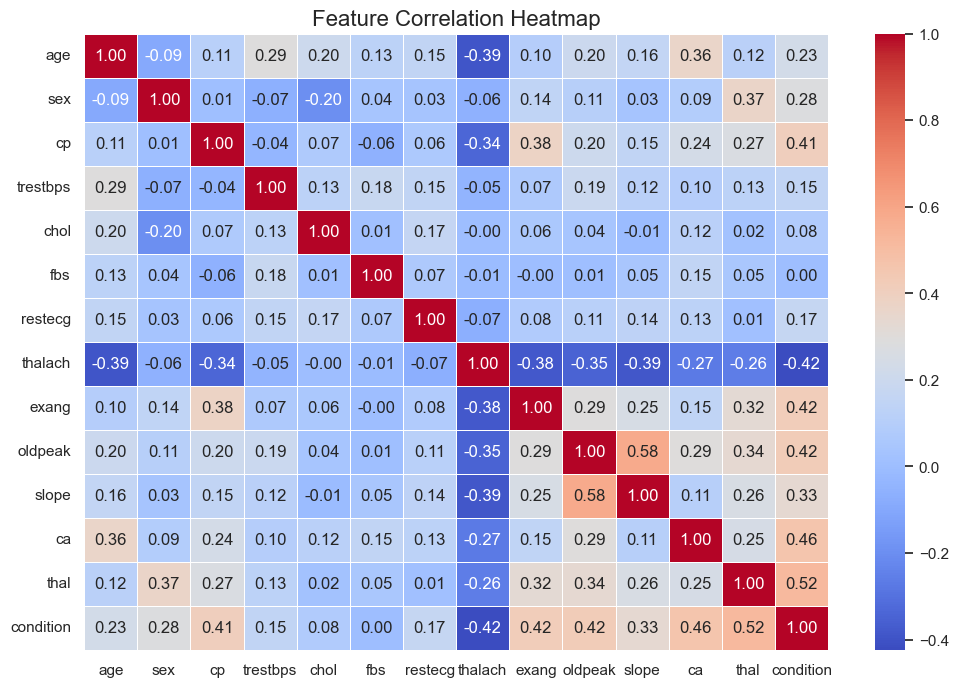


--- Preprocessing Complete ---
Training features shape: (237, 20)
Testing features shape: (60, 20)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

df= pd.read_csv('heart_cleveland_upload.csv')

print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

df.hist(figsize=(15,10), bins=20, color='teal', edgecolor='black')
plt.suptitle('Distribution of Heart Disease Features', fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap',fontsize=16)
plt.show()

continuous_cols = ['age', 'trestbps' , 'chol' , 'thalach' , 'oldpeak']

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

df[col] = np.clip(df[col], lower_bound, upper_bound)

categorical_cols = ['sex', 'cp' , 'fbs' , 'restecg' , 'exang' , 'slope' , 'ca', 'thal']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=['condition'])
y = df_encoded['condition']

X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("\n--- Preprocessing Complete ---")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")